In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [38]:
# Load the dataset
df = pd.read_csv('../data/raw/house_data.csv')
print("Dataset loaded successfully.")
print(df.shape)

Dataset loaded successfully.
(84, 7)


In [39]:
# Understand the data, schema, data types, missing values, etc.
print("Data Information:")
print(df.info())
# Summary statistics
print("Summary Statistics:")
print(df.describe())
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       84 non-null     int64  
 1   sqft        84 non-null     int64  
 2   bedrooms    84 non-null     int64  
 3   bathrooms   84 non-null     float64
 4   location    84 non-null     object 
 5   year_built  84 non-null     int64  
 6   condition   84 non-null     object 
dtypes: float64(1), int64(4), object(2)
memory usage: 4.7+ KB
None
Summary Statistics:
              price         sqft   bedrooms  bathrooms   year_built
count  8.400000e+01    84.000000  84.000000  84.000000    84.000000
mean   6.285595e+05  2191.500000   2.857143   2.190476  1982.047619
std    3.591678e+05   650.017117   0.852252   0.828356    19.501563
min    2.490000e+05  1350.000000   2.000000   1.000000  1947.000000
25%    3.742500e+05  1695.000000   2.000000   1.500000  1965.000000
50%    5.110000e

In [40]:
df.head()

,price,sqft,bedrooms,bathrooms,location,year_built,condition
0,495000,1527,2,1.5,Suburb,1956,Good
1,752000,2526,3,2.5,Downtown,1998,Excellent
2,319000,1622,2,1.5,Rural,1975,Fair
3,1210000,3102,4,3.0,Waterfront,2005,Excellent
4,462000,1835,2,2.0,Urban,1982,Good


In [41]:
# drop malformed rows
df = df.dropna()
print("Malformed rows dropped. New shape:", df.shape)

df = df[df['price'] > 10000]
print("Rows with price <= 10000 dropped. New shape:", df.shape)
df = df[df['sqft'] > 200]
print("Rows with sqft <= 200 dropped. New shape:", df.shape)

Malformed rows dropped. New shape: (84, 7)
Rows with price <= 10000 dropped. New shape: (84, 7)
Rows with sqft <= 200 dropped. New shape: (84, 7)


In [42]:
#standardize column names
print("Standardizing column names (lowercase and underscores)...")
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("Column names standardized.")
print("Updated column names:", df.columns.tolist())

Standardizing column names (lowercase and underscores)...
Column names standardized.
Updated column names: ['price', 'sqft', 'bedrooms', 'bathrooms', 'location', 'year_built', 'condition']


In [43]:
# Basic stats check (spot outliers, distributions, etc.)
print("Basic statistics check:")
print(df.describe())

Basic statistics check:
              price         sqft   bedrooms  bathrooms   year_built
count  8.400000e+01    84.000000  84.000000  84.000000    84.000000
mean   6.285595e+05  2191.500000   2.857143   2.190476  1982.047619
std    3.591678e+05   650.017117   0.852252   0.828356    19.501563
min    2.490000e+05  1350.000000   2.000000   1.000000  1947.000000
25%    3.742500e+05  1695.000000   2.000000   1.500000  1965.000000
50%    5.110000e+05  1995.000000   3.000000   2.000000  1982.500000
75%    7.292500e+05  2590.000000   3.000000   2.500000  1995.500000
max    1.680000e+06  3850.000000   5.000000   4.500000  2019.000000


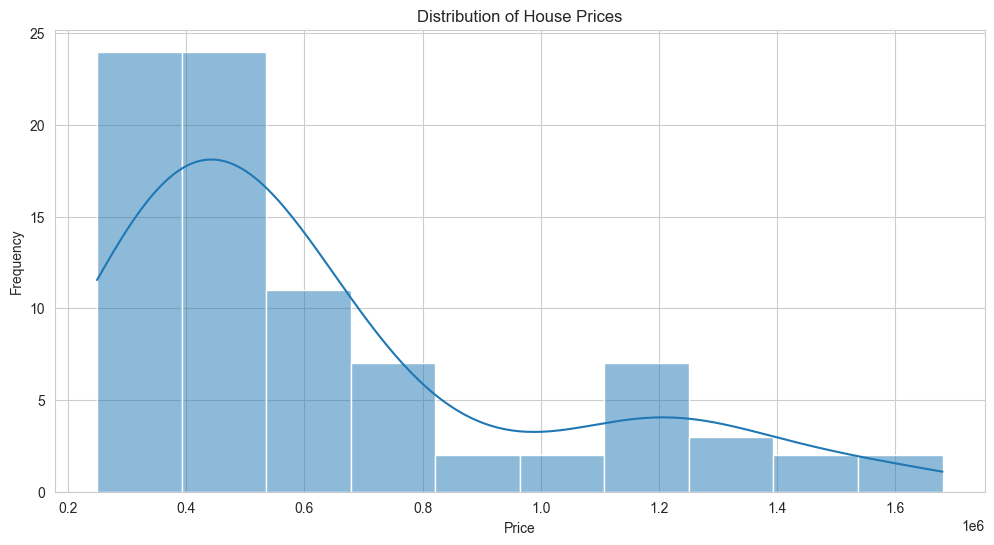

In [44]:
# visualize distributions of key features
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], bins=10, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [45]:
# check for obvious data issues
print("Checking for obvious data issues...")
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        invalid = df[df[col] < 0]
        if not invalid.empty:
            print(f"Found negative values in column '{col}':")
        else:
            print(f"No negative values found in column '{col}'.")

Checking for obvious data issues...
No negative values found in column 'price'.
No negative values found in column 'sqft'.
No negative values found in column 'bedrooms'.
No negative values found in column 'bathrooms'.
No negative values found in column 'year_built'.


In [46]:
# drop diplicates if any
print("Checking for duplicates...")
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows. Dropping duplicates...")
    df = df.drop_duplicates()
    print("Duplicates dropped. New shape:", df.shape)
else:
    print("No duplicate rows found.")

Checking for duplicates...
No duplicate rows found.


In [47]:
# save the cleaned data for the next steps
import os
print("Saving cleaned data to '../data/processed/house_data_cleaned.csv'...")
if not os.path.exists('../data/processed'):
    os.makedirs('../data/processed')
df.to_csv('../data/processed/house_data_cleaned.csv', index=False)
print("Cleaned data saved successfully.")

Saving cleaned data to '../data/processed/house_data_cleaned.csv'...
Cleaned data saved successfully.
